<a href="https://colab.research.google.com/github/nidhi-059/Deep-learning-projects/blob/main/DDPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
Tesla T4


In [ ]:
#sinusoidal positional embeddings
class SinusoidalPositionEmbeddings(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(10000) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            ) * -embeddings
        )

        embeddings = time[:, None] * embeddings[None, :]

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=-1
        )

        return embeddings

In [ ]:
#double convolution block
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):

        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1
            ),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),

            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1
            ),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
#down block
class Down(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch,
        time_dim
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.conv = DoubleConv(
            in_ch,
            out_ch
        )

        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                time_dim,
                out_ch
            )
        )

    def forward(self, x, t):

        x = self.pool(x)

        x = self.conv(x)

        emb = self.emb_layer(t)

        emb = emb[:, :, None, None]

        return x + emb

In [ ]:
#up block
class Up(nn.Module):

    def __init__(
        self,
        x_ch,
        skip_ch,
        out_ch,
        time_dim
    ):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            x_ch,
            x_ch // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            x_ch // 2 + skip_ch,
            out_ch
        )

        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

    def forward(self, x, skip, t):

        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        emb = self.emb_layer(t)

        return x + emb[:, :, None, None]

In [ ]:
#ddpm u net
class UNet(nn.Module):

    def __init__(
        self,
        c_in=3,
        c_out=3,
        time_dim=256
    ):

        super().__init__()

        self.time_dim = time_dim

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(
                time_dim
            ),
            nn.Linear(
                time_dim,
                time_dim
            ),
            nn.SiLU(),
            nn.Linear(
                time_dim,
                time_dim
            )
        )

        self.inc = DoubleConv(
            c_in,
            64
        )

        self.down1 = Down(
            64,
            128,
            time_dim
        )

        self.down2 = Down(
            128,
            256,
            time_dim
        )

        self.down3 = Down(
            256,
            512,
            time_dim
        )

        self.bot1 = DoubleConv(
            512,
            512
        )

        self.bot2 = DoubleConv(
            512,
            512
        )

        self.up1 = Up(
            512,
            256,
            256,
            time_dim
        )

        self.up2 = Up(
            256,
            128,
            128,
            time_dim
        )

        self.up3 = Up(
            128,
            64,
            64,
            time_dim
        )

        self.outc = nn.Conv2d(
            64,
            c_out,
            kernel_size=1
        )

    def forward(
        self,
        x,
        t
    ):

        t = self.time_mlp(t)

        x1 = self.inc(x)

        x2 = self.down1(
            x1,
            t
        )

        x3 = self.down2(
            x2,
            t
        )

        x4 = self.down3(
            x3,
            t
        )

        x4 = self.bot1(x4)

        x4 = self.bot2(x4)

        x = self.up1(
            x4,
            x3,
            t
        )

        x = self.up2(
            x,
            x2,
            t
        )

        x = self.up3(
            x,
            x1,
            t
        )

        return self.outc(x)

In [ ]:
#noise schedule
T = 1000

beta = torch.linspace(
    1e-4,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta

alpha_hat = torch.cumprod(
    alpha,
    dim=0
)

In [ ]:
#dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


In [ ]:
#helper functions
def sample_timesteps(batch_size):

    return torch.randint(
        low=0,
        high=T,
        size=(batch_size,),
        device=device
    )
def add_noise(x0, t):

    sqrt_alpha_hat = torch.sqrt(
        alpha_hat[t]
    )[:, None, None, None]

    sqrt_one_minus_alpha_hat = torch.sqrt(
        1 - alpha_hat[t]
    )[:, None, None, None]

    epsilon = torch.randn_like(x0)

    xt = (
        sqrt_alpha_hat * x0
        +
        sqrt_one_minus_alpha_hat * epsilon
    )

    return xt, epsilon

In [ ]:
#model
model = UNet(
    c_in=3,
    c_out=3
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [ ]:
#training loop
epochs = 50

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, _ in loader:

        images = images.to(device)

        t = sample_timesteps(
            images.size(0)
        )

        xt, noise = add_noise(
            images,
            t
        )

        predicted_noise = model(
            xt,
            t.float()
        )

        loss = F.mse_loss(
            predicted_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(
        f"Epoch {epoch+1}: {avg_loss:.4f}"
    )

    torch.save(
        model.state_dict(),
        "ddpm_unet.pth"
    )

Epoch 1: 0.1448
Epoch 2: 0.0562
Epoch 3: 0.0490
Epoch 4: 0.0458
Epoch 5: 0.0425
Epoch 6: 0.0424
Epoch 7: 0.0409
Epoch 8: 0.0401
Epoch 9: 0.0394
Epoch 10: 0.0382
Epoch 11: 0.0383
Epoch 12: 0.0376
Epoch 13: 0.0373
Epoch 14: 0.0366
Epoch 15: 0.0370
Epoch 16: 0.0364
Epoch 17: 0.0370
Epoch 18: 0.0365
Epoch 19: 0.0360
Epoch 20: 0.0358
Epoch 21: 0.0355
Epoch 22: 0.0363
Epoch 23: 0.0352
Epoch 24: 0.0353
Epoch 25: 0.0352
Epoch 26: 0.0349
Epoch 27: 0.0346
Epoch 28: 0.0351
Epoch 29: 0.0345
Epoch 30: 0.0341
Epoch 31: 0.0341
Epoch 32: 0.0340
Epoch 33: 0.0340
Epoch 34: 0.0346
Epoch 35: 0.0340
Epoch 36: 0.0338
Epoch 37: 0.0343
Epoch 38: 0.0333
Epoch 39: 0.0328
Epoch 40: 0.0336
Epoch 41: 0.0332
Epoch 42: 0.0340
Epoch 43: 0.0343
Epoch 44: 0.0335
Epoch 45: 0.0339
Epoch 46: 0.0333
Epoch 47: 0.0339
Epoch 48: 0.0332
Epoch 49: 0.0334
Epoch 50: 0.0328


In [ ]:
#reverse sampling
@torch.no_grad()
def sample(model, n):

    model.eval()

    x = torch.randn(
        n,
        3,
        32,
        32,
        device=device
    )

    for i in reversed(range(T)):

        t = torch.full(
            (n,),
            i,
            device=device
        ).float()

        pred_noise = model(
            x,
            t
        )

        alpha_t = alpha[i]
        alpha_hat_t = alpha_hat[i]
        beta_t = beta[i]

        if i > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x -
            (
                (1 - alpha_t)
                / torch.sqrt(1 - alpha_hat_t)
            ) * pred_noise
        ) + torch.sqrt(beta_t) * z

    return x

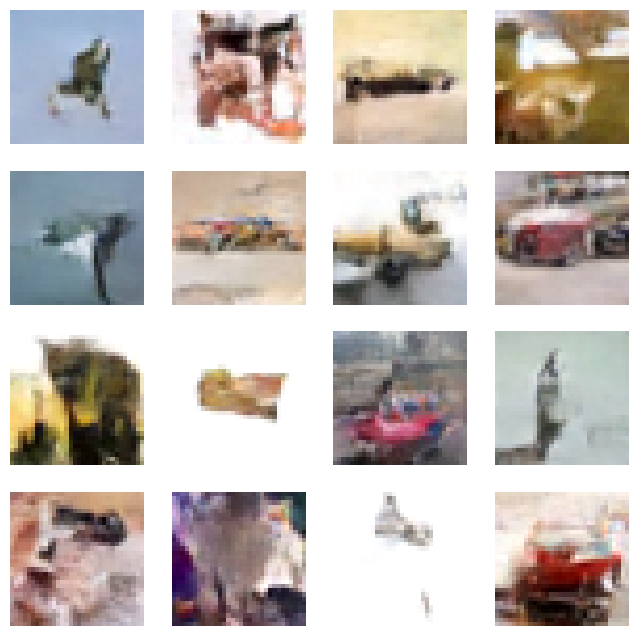

In [ ]:
#visualize samles;
import matplotlib.pyplot as plt

samples = sample(
    model,
    16
)

samples = (
    samples.clamp(-1,1)
    + 1
) / 2

fig, ax = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for i in range(16):

    img = samples[i].cpu()

    img = img.permute(
        1,
        2,
        0
    )

    ax[i//4][i%4].imshow(img)
    ax[i//4][i%4].axis("off")

plt.show()

In [ ]:
x = torch.randn(2,3,32,32).to(device)
t = torch.randint(0,1000,(2,)).float().to(device)

print(model(x,t).shape)
torch.Size([2, 3, 32, 32])

torch.Size([2, 3, 32, 32])


torch.Size([2, 3, 32, 32])